In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Please adjust the file path to match your PC environment
!ls '/content/drive/MyDrive/latent_flow_git/'
%cd "/content/drive/MyDrive/latent_flow_git/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data  program  results	trained_model
/content/drive/MyDrive/latent_flow_git


In [ ]:
# Import the required libraries and functions
import os, glob
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.io import savemat
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from program.utils import plot_stick_figure
from program.model import (MoCapVAEDataset, TrajectoryVAE, kld_normal, compute_per_timestep_rmse,
                           compute_per_timestep_rmse_masked, export_test_and_pred_to_mat,
                           compute_latent_trajectories_3d_from_ds_std)

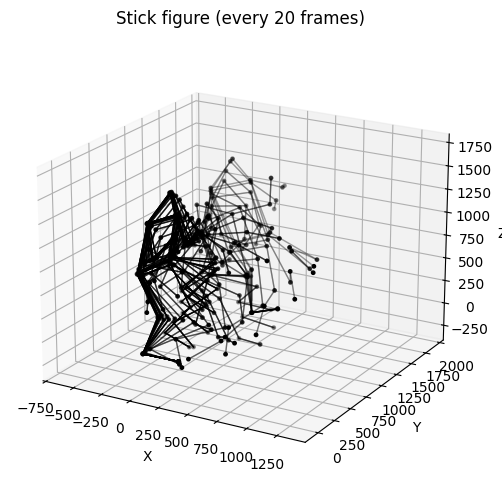

Raw X_full: torch.Size([150, 391, 45])  X_ds: torch.Size([150, 195, 45])


In [ ]:
# Load pitching motion data
sub_name="sub01" #01~08
mocap_path = "./data/mocap/"+sub_name+".mat"
edge_path = "./data/edge_index.mat"

X_list = []
mat = sio.loadmat(mocap_path)
X_subj = np.squeeze(np.array(mat["X"]))
X_list.append(X_subj)

X = np.concatenate(X_list, axis=0)
N, T, D = X.shape # N: data num, T: frame num, D: feature num
J = D // 3

# Connection information between joints
edge_mat = sio.loadmat(edge_path)
edge_index = np.array(edge_mat["edge_index"]).astype(np.int64)
edge_index = np.squeeze(edge_index)
E = edge_index.shape[0]

# Plot and check the original motion
plt.rcParams["figure.figsize"] = (6, 6)
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

positions_0 = X[0].reshape(T, J, 3)  # [T,J,3]
plot_stick_figure(positions_0, edge_index, color="black", ax=ax)
plt.show()

# Fix the random seed
seed = 0
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dawnsample the data from 200 hz to 100 hz
DS = 2
T_ds = T // DS
t_idx_ds = torch.arange(0, T_ds * DS, DS)

X_full = torch.from_numpy(X).float()
X_ds   = X_full[:, t_idx_ds, :]

print("Raw X_full:", X_full.shape, " X_ds:", X_ds.shape)

In [ ]:
# If you want to re-run the model training, please set "model_train = 1"
model_train = 0

# Make 10 datasets (9 for train and 1 for test)
N = X_full.shape[0]
dataset_num = 10
perm = np.random.RandomState(seed).permutation(N)
folds = np.array_split(perm, dataset_num)

# Set model parameter
# Latent dimension (1, 2, 3, 4, 8, 16, 32)
d_latent = 2

# Model parameter setting (light, middle, heavy)
d_model = 256; nhead = 8
num_layers_enc = 3; num_layers_dec = 3
dim_ff = 256

# Set other (fixed) parameters
K = 12
dropout = 0.0
lr = 1e-4
lambda_recon = 1.0
lambda_kl = 0.001
epoch = 1500
batch_size = 32

if model_train == 1:
    save_dir = f"./trained_model/{sub_name}"
    os.makedirs(save_dir, exist_ok=True)

    for set_id in range(dataset_num):
        model_out_name = f"set{set_id:02d}_d{d_latent:02d}.pth"

        idx_te_np = folds[set_id]
        idx_tr_np = np.concatenate([folds[i] for i in range(dataset_num) if i != set_id])

        idx_tr = torch.as_tensor(idx_tr_np, dtype=torch.long, device=X_full.device)
        idx_te = torch.as_tensor(idx_te_np, dtype=torch.long, device=X_full.device)

        X_full_tr_phys = X_full[idx_tr]
        X_full_te_phys = X_full[idx_te]
        X_ds_tr_phys   = X_ds[idx_tr]
        X_ds_te_phys   = X_ds[idx_te]

        D = X_full_tr_phys.shape[-1]
        flat_tr = X_full_tr_phys.reshape(-1, D)
        mean_train = flat_tr.mean(dim=0)
        std_train  = flat_tr.std(dim=0) + 1e-8

        def standardize(X_phys, mean=mean_train, std=std_train):
            return (X_phys - mean) / std

        # To avoid data leakage, normalize the test data based on the training data
        X_full_tr_std = standardize(X_full_tr_phys)
        X_full_te_std = standardize(X_full_te_phys)

        X_ds_tr_std   = standardize(X_ds_tr_phys)
        X_ds_te_std   = standardize(X_ds_te_phys)

        train_dataset = MoCapVAEDataset(X_full_tr_std, X_ds_tr_std)
        test_dataset  = MoCapVAEDataset(X_full_te_std, X_ds_te_std)

        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

        model = TrajectoryVAE(D, d_model, nhead, num_layers_enc, num_layers_dec,dim_ff, dropout, K, d_latent, T).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

        # Run training
        model.train()
        for ep in range(1, epoch + 1):
            tot = rec_tot = kld_tot = 0.0
            n = 0

            for x_ds_b, x_full_b in train_loader:
                x_ds_b   = x_ds_b.to(device)
                x_full_b = x_full_b.to(device)

                x_hat_b, mu_b, logvar_b, C_b, zK_b, zT_b = model(x_ds_b, deterministic=False)

                sq_err = (x_hat_b - x_full_b) ** 2
                mse_t = sq_err.mean(dim=-1)

                T_full = x_full_b.size(1)
                w = torch.ones(T_full, device=device)
                w[-1] = 10.0
                rec = (mse_t * w.view(1, T_full)).mean()

                kld = kld_normal(mu_b, logvar_b).mean()

                loss = lambda_recon * rec + lambda_kl * kld

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                B = x_ds_b.size(0)
                tot     += loss.item() * B
                rec_tot += rec.item()  * B
                kld_tot += kld.item()  * B
                n += B

            print(f"[set{set_id:02d}] [{ep}/{epoch}] "
                  f"loss={tot/n:.6f} rec={rec_tot/n:.6f} kld={kld_tot/n:.6f}")

        # Save the leraned model
        save_path = os.path.join(save_dir, model_out_name)
        torch.save(model.state_dict(), save_path)
        print(f"Model saved to {save_path}")

Saved figure to ./results/sub08/sub08_d02_rmse_baseline.tiff


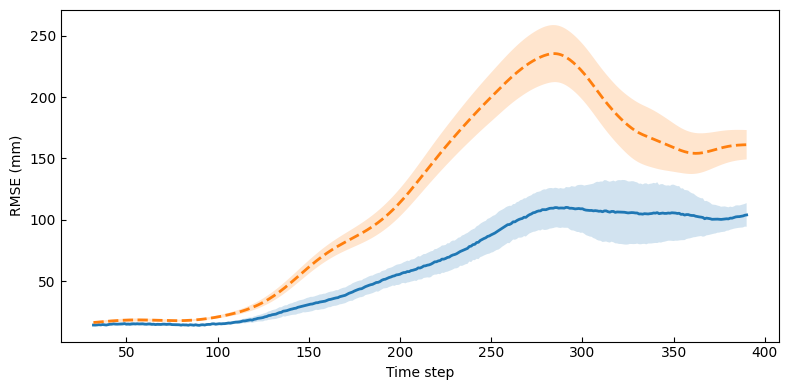

Overall RMSE (model, mean over time): 58.23441
Overall RMSE (time-mean base, mean over time): 108.58875
Saved CSV to ./results/sub08/sub08_d02_rmse_model.csv


In [ ]:
results_dir = f"./results/{sub_name}"
os.makedirs(results_dir, exist_ok=True)

perm = np.random.RandomState(seed).permutation(N)
folds = np.array_split(perm, dataset_num)

rmse_model_all = []
rmse_base_all = []

trained_dir = f"./trained_model/{sub_name}"

for set_id in range(dataset_num):
    model_load_name = f"set{set_id:02d}_d{d_latent:02d}.pth"

    idx_te_np = folds[set_id]
    idx_tr_np = np.concatenate([folds[i] for i in range(dataset_num) if i != set_id])

    idx_tr = torch.as_tensor(idx_tr_np, dtype=torch.long, device=X_full.device)
    idx_te = torch.as_tensor(idx_te_np, dtype=torch.long, device=X_full.device)

    X_full_tr_phys = X_full[idx_tr]
    X_full_te_phys = X_full[idx_te]
    X_ds_te_phys = X_ds[idx_te]

    D_ = X_full_tr_phys.shape[-1]
    flat_tr = X_full_tr_phys.reshape(-1, D_)

    mean_train = flat_tr.mean(dim=0)
    std_train = flat_tr.std(dim=0) + 1e-8
    mean_train_t = X_full_tr_phys.mean(dim=0)

    X_ds_te_std = (
        X_ds_te_phys - mean_train.view(1, 1, -1)
    ) / std_train.view(1, 1, -1)

    load_path = os.path.join(trained_dir, model_load_name)

    model = TrajectoryVAE(
        D_,
        d_model,
        nhead,
        num_layers_enc,
        num_layers_dec,
        dim_ff,
        dropout,
        K,
        d_latent,
        T
    ).to(device)

    model.load_state_dict(torch.load(load_path, map_location=device))
    model.eval()

    rmse_model_t, rmse_base_t = compute_per_timestep_rmse(
        model,
        X_ds_te_std=X_ds_te_std,
        X_full_te_phys=X_full_te_phys,
        mean_train=mean_train,
        std_train=std_train,
        mean_train_t=mean_train_t,
        device=device
    )

    rmse_model_all.append(rmse_model_t)
    rmse_base_all.append(rmse_base_t)

rmse_model_all = np.stack(rmse_model_all, axis=0)
rmse_base_all = np.stack(rmse_base_all, axis=0)

rmse_model_mean = rmse_model_all.mean(axis=0)
rmse_model_sd = rmse_model_all.std(axis=0)

rmse_base_mean = rmse_base_all.mean(axis=0)
rmse_base_sd = rmse_base_all.std(axis=0)

K_ignore = T // K
timesteps = np.arange(T)[K_ignore:]

m_mean = rmse_model_mean[K_ignore:]
m_lo = (rmse_model_mean - rmse_model_sd)[K_ignore:]
m_hi = (rmse_model_mean + rmse_model_sd)[K_ignore:]

b_mean = rmse_base_mean[K_ignore:]
b_lo = (rmse_base_mean - rmse_base_sd)[K_ignore:]
b_hi = (rmse_base_mean + rmse_base_sd)[K_ignore:]

plt.figure(figsize=(8, 4))

plt.plot(timesteps, m_mean, label="Proposed", linewidth=2)
plt.fill_between(timesteps, m_lo, m_hi, alpha=0.2)

plt.plot(timesteps, b_mean, label="Train time-mean", linestyle="--", linewidth=2)
plt.fill_between(timesteps, b_lo, b_hi, alpha=0.2)

plt.xlabel("Time step")
plt.ylabel("RMSE (mm)")
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.tight_layout()

fig_path = os.path.join(
    results_dir,
    f"{sub_name}_d{d_latent:02d}_rmse_baseline.tiff"
)

plt.savefig(fig_path, dpi=300, format="tiff", bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

print("Overall RMSE (model, mean over time):", rmse_model_mean.mean())
print("Overall RMSE (time-mean base, mean over time):", rmse_base_mean.mean())

csv_path = os.path.join(
    results_dir,
    f"{sub_name}_d{d_latent:02d}_rmse_model.csv"
)

df = pd.DataFrame({
    "timestep": np.arange(T),
    "rmse_model_mean": rmse_model_mean,
    "rmse_model_sd": rmse_model_sd,
    "rmse_base_mean": rmse_base_mean,
    "rmse_base_sd": rmse_base_sd,
})

df.to_csv(csv_path, index=False)
print(f"Saved CSV to {csv_path}")

Loaded model: ./trained_model/sub08/set00_d02.pth


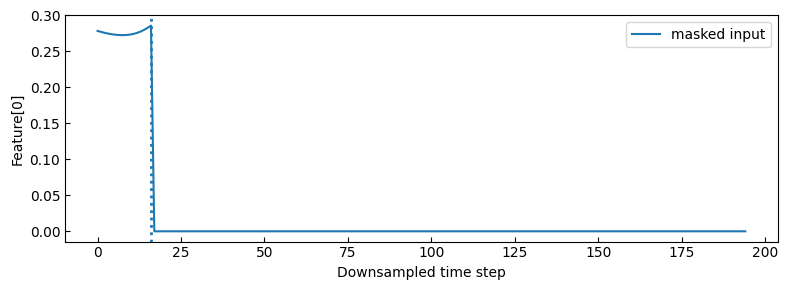

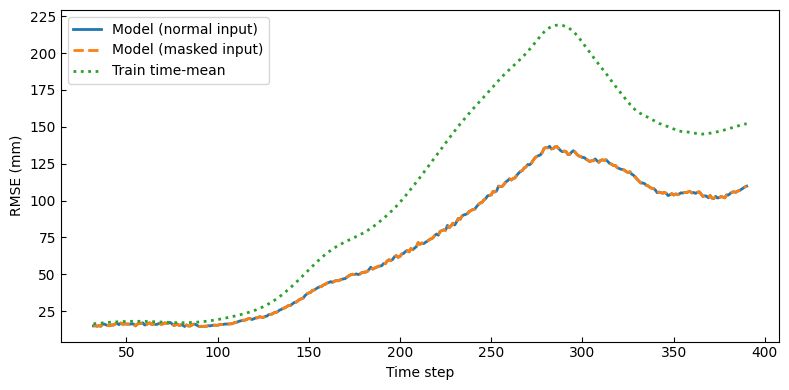

Overall RMSE (model, normal)      : 65.615616
Overall RMSE (model, masked)      : 65.615616
Overall RMSE (time-mean baseline) : 98.85538


In [ ]:
set_id = 0
idx_te_np = folds[set_id]
idx_tr_np = np.concatenate([folds[i] for i in range(dataset_num) if i != set_id])

idx_tr = torch.as_tensor(idx_tr_np, dtype=torch.long, device=X_full.device)
idx_te = torch.as_tensor(idx_te_np, dtype=torch.long, device=X_full.device)

X_full_tr_phys = X_full[idx_tr]
X_full_te_phys = X_full[idx_te]
X_ds_te_phys = X_ds[idx_te]

D_ = X_full_tr_phys.shape[-1]
flat_tr = X_full_tr_phys.reshape(-1, D_)

mean_train = flat_tr.mean(dim=0)
std_train = flat_tr.std(dim=0) + 1e-8
mean_train_t = X_full_tr_phys.mean(dim=0)

X_ds_te_std = (
    X_ds_te_phys - mean_train.view(1, 1, -1)
) / std_train.view(1, 1, -1)

model_load_name = f"set{set_id:02d}_d{d_latent:02d}.pth"
load_path = os.path.join(trained_dir, model_load_name)

model = TrajectoryVAE(
    D_,
    d_model,
    nhead,
    num_layers_enc,
    num_layers_dec,
    dim_ff,
    dropout,
    K,
    d_latent,
    T
).to(device)

model.load_state_dict(torch.load(load_path, map_location=device))
model.eval()
print(f"Loaded model: {load_path}")

_, T_ds, _ = X_ds_te_std.shape
base = T_ds // K
remainder = T_ds % K
seg0_end = base + (1 if remainder > 0 else 0)

sample_idx = 0
feat_idx = 0

x_ds_std_one = X_ds_te_std[sample_idx:sample_idx+1].clone()

x_ds_std_masked_one = x_ds_std_one.clone()
x_ds_std_masked_one[:, seg0_end:, :] = 0.0

x_plot = x_ds_std_one[0, :, feat_idx].detach().cpu().numpy()
x_plot_mask = x_ds_std_masked_one[0, :, feat_idx].detach().cpu().numpy()
t_ds = np.arange(T_ds)

plt.figure(figsize=(8, 3))
plt.plot(t_ds, x_plot_mask, label="masked input")
plt.axvline(seg0_end - 1, linestyle=":", linewidth=2)
plt.xlabel("Downsampled time step")
plt.ylabel(f"Feature[{feat_idx}]")
plt.legend()
plt.tight_layout()
plt.show()

rmse_model_t, rmse_base_t = compute_per_timestep_rmse(
    model,
    X_ds_te_std=X_ds_te_std,
    X_full_te_phys=X_full_te_phys,
    mean_train=mean_train,
    std_train=std_train,
    mean_train_t=mean_train_t,
    device=device
)

rmse_model_t_masked, rmse_base_t_masked = compute_per_timestep_rmse_masked(
    model,
    X_ds_te_std=X_ds_te_std,
    X_full_te_phys=X_full_te_phys,
    mean_train=mean_train,
    std_train=std_train,
    mean_train_t=mean_train_t,
    K=K,
    device=device
)

K_ignore = T // K
timesteps = np.arange(T)[K_ignore:]

plt.figure(figsize=(8, 4))
plt.plot(timesteps, rmse_model_t[K_ignore:], label="Model (normal input)", linewidth=2)
plt.plot(timesteps, rmse_model_t_masked[K_ignore:], label="Model (masked input)", linewidth=2, linestyle="--")
plt.plot(timesteps, rmse_base_t[K_ignore:], label="Train time-mean", linestyle=":", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("RMSE (mm)")
plt.legend()
plt.tight_layout()
plt.show()

print("Overall RMSE (model, normal)      :", rmse_model_t.mean())
print("Overall RMSE (model, masked)      :", rmse_model_t_masked.mean())
print("Overall RMSE (time-mean baseline) :", rmse_base_t.mean())

In [ ]:
latent_shift_dir = os.path.join(results_dir, "latent_shift")
os.makedirs(latent_shift_dir, exist_ok=True)

set_id = 0
shift_value = 0.1

idx_te_np = folds[set_id]
idx_tr_np = np.concatenate([folds[i] for i in range(dataset_num) if i != set_id])

idx_tr = torch.as_tensor(idx_tr_np, dtype=torch.long, device=X_full.device)
idx_te = torch.as_tensor(idx_te_np, dtype=torch.long, device=X_full.device)

X_full_tr_phys = X_full[idx_tr]
X_ds_te_phys = X_ds[idx_te]

D_ = X_full_tr_phys.shape[-1]
flat_tr = X_full_tr_phys.reshape(-1, D_)

mean_train = flat_tr.mean(dim=0)
std_train = flat_tr.std(dim=0) + 1e-8

X_ds_te_std = (
    X_ds_te_phys - mean_train.view(1, 1, -1)
) / std_train.view(1, 1, -1)

_, T_ds, _ = X_ds_te_std.shape
base = T_ds // K
remainder = T_ds % K
seg0_end = base + (1 if remainder > 0 else 0)

X_ds_te_std_masked = X_ds_te_std.clone()
X_ds_te_std_masked[:, seg0_end:, :] = 0.0

model_load_name = f"set{set_id:02d}_d{d_latent:02d}.pth"
load_path = os.path.join(trained_dir, model_load_name)

model = TrajectoryVAE(
    D_,
    d_model,
    nhead,
    num_layers_enc,
    num_layers_dec,
    dim_ff,
    dropout,
    K,
    d_latent,
    T
).to(device)

model.load_state_dict(torch.load(load_path, map_location=device))
model.eval()

print(f"[set{set_id:02d}] Loaded {load_path}")

with torch.no_grad():
    mu, logvar = model.enc(X_ds_te_std_masked)
    C = model.reparameterize(mu, logvar, deterministic=True)

    ztraj_T = model.cnf_traj_full(C)

    N_te, T_full, D_z = ztraj_T.shape
    t_norm = model.t_grid_full.view(1, -1, 1).expand(N_te, -1, -1)

    ztraj_z1 = ztraj_T.clone()
    ztraj_z1[:, :, 0] = ztraj_z1[:, :, 0] + shift_value

    ztraj_z2 = ztraj_T.clone()
    ztraj_z2[:, :, 1] = ztraj_z2[:, :, 1] + shift_value

    x_z1_std = model.step_dec(ztraj_z1, t_norm=t_norm)
    x_z2_std = model.step_dec(ztraj_z2, t_norm=t_norm)

    x_z1_phys = x_z1_std * std_train.view(1, 1, -1) + mean_train.view(1, 1, -1)
    x_z2_phys = x_z2_std * std_train.view(1, 1, -1) + mean_train.view(1, 1, -1)

    K_ignore = T_full // K

    X_z1 = x_z1_phys[:, K_ignore:, :].detach().cpu().numpy().astype(np.float32)
    X_z2 = x_z2_phys[:, K_ignore:, :].detach().cpu().numpy().astype(np.float32)

mat_path = os.path.join(
    latent_shift_dir,
    f"set{set_id:02d}_d{d_latent:02d}_latent_shift.mat"
)

savemat(mat_path, {
    "X_z1": X_z1,
    "X_z2": X_z2,
})

print(f"[set{set_id:02d}] Saved MAT to {mat_path}")

[set00] Loaded ./trained_model/sub08/set00_d02.pth
[set00] Saved CSV to ./results/sub08/latent_trajectory/set00_d02_latent_trajectory.csv
Saved mat to ./results/sub08/prediction/set00_d02_jpositions.mat
[set01] Loaded ./trained_model/sub08/set01_d02.pth
[set01] Saved CSV to ./results/sub08/latent_trajectory/set01_d02_latent_trajectory.csv
Saved mat to ./results/sub08/prediction/set01_d02_jpositions.mat
[set02] Loaded ./trained_model/sub08/set02_d02.pth
[set02] Saved CSV to ./results/sub08/latent_trajectory/set02_d02_latent_trajectory.csv
Saved mat to ./results/sub08/prediction/set02_d02_jpositions.mat
[set03] Loaded ./trained_model/sub08/set03_d02.pth
[set03] Saved CSV to ./results/sub08/latent_trajectory/set03_d02_latent_trajectory.csv
Saved mat to ./results/sub08/prediction/set03_d02_jpositions.mat
[set04] Loaded ./trained_model/sub08/set04_d02.pth
[set04] Saved CSV to ./results/sub08/latent_trajectory/set04_d02_latent_trajectory.csv
Saved mat to ./results/sub08/prediction/set04_d02_

In [ ]:
# Shift the coordinates in the latent space and reconstruct the motion
latent_shift_dir = "./results/latent_shit"
os.makedirs(latent_shift_dir, exist_ok=True)

set_id = 0
shift_value = 0.5 
d_latent = 2 # fixed

idx_te_np = folds[set_id]
idx_tr_np = np.concatenate([folds[i] for i in range(dataset_num) if i != set_id])
idx_tr = torch.as_tensor(idx_tr_np, dtype=torch.long, device=X_full.device)
idx_te = torch.as_tensor(idx_te_np, dtype=torch.long, device=X_full.device)

X_full_tr_phys = X_full[idx_tr]
X_ds_te_phys = X_ds[idx_te]

D_ = X_full_tr_phys.shape[-1]
flat_tr = X_full_tr_phys.reshape(-1, D_)

mean_train = flat_tr.mean(dim=0)
std_train = flat_tr.std(dim=0) + 1e-8

X_ds_te_std = (
    X_ds_te_phys - mean_train.view(1, 1, -1)
) / std_train.view(1, 1, -1)

_, T_ds, _ = X_ds_te_std.shape
base = T_ds // K
remainder = T_ds % K
seg0_end = base + (1 if remainder > 0 else 0)

X_ds_te_std_masked = X_ds_te_std.clone()
X_ds_te_std_masked[:, seg0_end:, :] = 0.0

trained_dir = f"./trained_model/{sub_name}"
model_load_name = f"set{set_id:02d}_d{d_latent:02d}.pth"
load_path = os.path.join(trained_dir, model_load_name)

model = TrajectoryVAE(
    D_,
    d_model,
    nhead,
    num_layers_enc,
    num_layers_dec,
    dim_ff,
    dropout,
    K,
    d_latent,
    T
).to(device)

model.load_state_dict(torch.load(load_path, map_location=device))
model.eval()

print(f"Loaded model: {load_path}")

with torch.no_grad():
    mu, logvar = model.enc(X_ds_te_std_masked)
    C = model.reparameterize(mu, logvar, deterministic=True)

    ztraj_T = model.cnf_traj_full(C)

    N_te, T_full, D_z = ztraj_T.shape
    t_norm = model.t_grid_full.view(1, -1, 1).expand(N_te, -1, -1)

    ztraj_z1 = ztraj_T.clone()
    ztraj_z1[:, :, 0] = ztraj_z1[:, :, 0] + shift_value

    ztraj_z2 = ztraj_T.clone()
    ztraj_z2[:, :, 1] = ztraj_z2[:, :, 1] + shift_value

    x_z1_std = model.step_dec(ztraj_z1, t_norm=t_norm)
    x_z2_std = model.step_dec(ztraj_z2, t_norm=t_norm)

    x_z1_phys = x_z1_std * std_train.view(1, 1, -1) + mean_train.view(1, 1, -1)
    x_z2_phys = x_z2_std * std_train.view(1, 1, -1) + mean_train.view(1, 1, -1)

    K_ignore = T_full // K

    X_z1 = x_z1_phys[:, K_ignore:, :].detach().cpu().numpy().astype(np.float32)
    X_z2 = x_z2_phys[:, K_ignore:, :].detach().cpu().numpy().astype(np.float32)

mat_path = os.path.join(
    latent_shift_dir,
    f"{sub_name}_d{d_latent:02d}.mat"
)

savemat(mat_path, {
    "X_z1": X_z1,
    "X_z2": X_z2,
})

print(f"Saved MAT to {mat_path}")

In [ ]:
from google.colab import runtime
runtime.unassign()